# **Regional Sales Analysis**

In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Configure notebook display
%matplotlib inline
sns.set_style("whitegrid")    # clean seaborn style
plt.rcParams['figure.figsize'] = (10, 6)   # default fig size

In [ ]:
sheets = pd.read_excel("/content/Regional Sales Dataset.xlsx", sheet_name = None)

In [ ]:
#  Assign dataframes to each sheet

df_sales = sheets['Sales Orders']
df_customers = sheets['Customers']
df_products = sheets['Products']
df_regions = sheets['Regions']
df_state_reg = sheets['State Regions']
df_budgets = sheets['2017 Budgets']

In [ ]:
print("df_sales.shape:",df_sales.shape)
print("df_customers.shape:",df_customers.shape)
print("df_products.shape:",df_products.shape)
print("df_regions.shape:",df_regions.shape)
print("df_state_reg.shape:",df_state_reg.shape)
print("df_budgets.shape:",df_budgets.shape)


df_sales.shape: (64104, 12)
df_customers.shape: (175, 2)
df_products.shape: (30, 2)
df_regions.shape: (994, 15)
df_state_reg.shape: (48, 3)
df_budgets.shape: (30, 2)


In [ ]:
df_sales.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 0008865,2014-01-01,53,Wholesale,USD,GUT930,540,1,7,2874.3,20120.1,1667.094
1,SO - 0004792,2014-01-03,141,Wholesale,USD,AXW291,219,1,6,167.5,1005.0,83.750
2,SO - 0003563,2014-01-03,160,Wholesale,USD,GUT930,202,1,12,1165.8,13989.6,827.718
3,SO - 0004196,2014-01-04,11,Distributor,USD,GUT930,397,1,6,1011.7,6070.2,829.594
4,SO - 0002523,2014-01-04,15,Export,USD,AXW291,799,1,5,3999.9,19999.5,1639.959


In [ ]:
df_customers.head(5)

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [ ]:
df_products.head(5)

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [ ]:
df_regions.head(5)

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [ ]:
df_state_reg.head(5)

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [ ]:
df_budgets.head(5)

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [ ]:
df_sales.isnull().sum()

,0
OrderNumber,0
OrderDate,0
Customer Name Index,0
Channel,0
Currency Code,0
Warehouse Code,0
Delivery Region Index,0
Product Description Index,0
Order Quantity,0
Unit Price,0


In [ ]:
df_customers.isnull().sum()

,0
Customer Index,0
Customer Names,0


In [ ]:
df_products.isnull().sum()

,0
Index,0
Product Name,0


In [ ]:
df_regions.isnull().sum()

,0
id,0
name,0
county,0
state_code,0
state,0
type,0
latitude,0
longitude,0
area_code,0
population,0


In [ ]:
df_state_reg.isnull().sum()

,0
State Code,0
State,0
Region,0


In [ ]:
df_budgets.isnull().sum()

,0
Product Name,0
2017 Budgets,0


In [ ]:
df_sales.duplicated().sum()

np.int64(0)

In [ ]:
df_customers.isnull().sum()

,0
Customer Index,0
Customer Names,0


In [ ]:
df_products.duplicated().sum()

np.int64(0)

In [ ]:
df_regions.duplicated().sum()

np.int64(0)

In [ ]:
df_state_reg.duplicated().sum()

np.int64(0)

In [ ]:
df_budgets.duplicated().sum()

np.int64(0)

**Data Cleaning & wrangling**

In [ ]:
# Data Wrangling & Merging
# Merge with Customers
df = df_sales.merge(
    df_customers,
    how = 'left',
    left_on = 'Customer Name Index',
    right_on = 'Customer Index')



In [ ]:
# Merge with Products
df = df.merge(
    df_products,
    how = 'left',
    left_on = 'Product Description Index',
    right_on = 'Index'
)

In [ ]:
# Merge with Regions
df = df.merge(
    df_regions,
    how = 'left',
    left_on = 'Delivery Region Index',
    right_on = 'id'
)

In [ ]:
# Merge with State Regions
df = df.merge(
    df_state_reg[["State Code","Region"]],
    how = 'left',
    left_on = 'state_code',
    right_on = 'State Code'
)

In [ ]:
# Merge with Budgets

df = df.merge(df_budgets,
         how = 'left',
         on = 'Product Name')

In [ ]:
df.shape

(64104, 34)

In [ ]:
#   Clean up redundant columns
cols_to_drop =  ['Customer Index', 'Index','id','State Code']

df = df.drop(columns = cols_to_drop, errors = 'ignore')

df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 0008865,2014-01-01,53,Wholesale,USD,GUT930,540,1,7,2874.3,...,-71.14200,857,59195,25324,95518,17508399,184972,America/New York,Northeast,3016489.209
1,SO - 0004792,2014-01-03,141,Wholesale,USD,AXW291,219,1,6,167.5,...,-118.03284,562,87438,27525,66457,37940391,40476,America/Los Angeles,West,3016489.209
2,SO - 0003563,2014-01-03,160,Wholesale,USD,GUT930,202,1,12,1165.8,...,-118.34063,424,148475,55377,79549,53038407,194217,America/Los Angeles,West,3016489.209
3,SO - 0004196,2014-01-04,11,Distributor,USD,GUT930,397,1,6,1011.7,...,-88.96991,309,78292,31110,62254,70308044,24508,America/Chicago,Midwest,3016489.209
4,SO - 0002523,2014-01-04,15,Export,USD,AXW291,799,1,5,3999.9,...,-98.39033,580,96655,33255,42493,209876261,0,America/Chicago,South,3016489.209


In [ ]:
# Convert all column names to lowercase for consistency and easier access
df.columns = df.columns.str.lower()

df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

In [ ]:
# dropping unnecessary columns and renaming for clarity

cols_to_keep = [
    'ordernumber',
    'orderdate',
    'customer names',
    'channel',
    'order quantity',
    'unit price',
    'total unit cost',
    'product name',
    'state_code',
    'state',
    'latitude',
    'longitude' ,
    'region',
    'line total',
    '2017 budgets' ]




df = df[cols_to_keep]

# renaming

df = df.rename(columns ={
   'ordernumber'      : 'order_number',
    'orderdate'       : 'order_date',
    'customer names'  : 'customer_name',
    'order quantity'  : 'quantity',
    'unit price'      :'unit_price',
    'total unit cost' : 'cost',
    'product name'    : 'product_name',
    'state_code'      :'state',
    'state'           : 'state_name',
    'latitude'        :'lat',
    'longitude'       : 'lon',
    'region'          :'us_region',
    'line total'      :'revenue',
    '2017 budgets'    : 'budget'
})



In [ ]:
df.head()

,order_number,order_date,customer_name,channel,quantity,unit_price,cost,product_name,state,state_name,lat,lon,us_region,revenue,budget
0,SO - 0008865,2014-01-01,Kare Corp,Wholesale,7,2874.3,1667.094,Product 1,MA,Massachusetts,42.32385,-71.14200,Northeast,20120.1,3016489.209
1,SO - 0004792,2014-01-03,Skinder Group,Wholesale,6,167.5,83.750,Product 1,CA,California,33.97918,-118.03284,West,1005.0,3016489.209
2,SO - 0003563,2014-01-03,Browsebug Company,Wholesale,12,1165.8,827.718,Product 1,CA,California,33.83585,-118.34063,West,13989.6,3016489.209
3,SO - 0004196,2014-01-04,Voonyx Group,Distributor,6,1011.7,829.594,Product 1,IL,Illinois,40.47578,-88.96991,Midwest,6070.2,3016489.209
4,SO - 0002523,2014-01-04,Centizu Company,Export,5,3999.9,1639.959,Product 1,OK,Oklahoma,34.60869,-98.39033,South,19999.5,3016489.209


In [ ]:
# Blank out budgets for non - 2017 orders

df.loc[df['order_date'].dt.year != 2017, 'budget'] = pd.NA

df[['order_date','product_name','revenue','budget']].head(5)



,order_date,product_name,revenue,budget
0,2014-01-01,Product 1,20120.1,NaN
1,2014-01-03,Product 1,1005.0,NaN
2,2014-01-03,Product 1,13989.6,NaN
3,2014-01-04,Product 1,6070.2,NaN
4,2014-01-04,Product 1,19999.5,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_number   64104 non-null  object        
 1   order_date     64104 non-null  datetime64[ns]
 2   customer_name  64104 non-null  object        
 3   channel        64104 non-null  object        
 4   quantity       64104 non-null  int64         
 5   unit_price     64104 non-null  float64       
 6   cost           64104 non-null  float64       
 7   product_name   64104 non-null  object        
 8   state          64104 non-null  object        
 9   state_name     64104 non-null  object        
 10  lat            64104 non-null  float64       
 11  lon            64104 non-null  float64       
 12  us_region      64104 non-null  object        
 13  revenue        64104 non-null  float64       
 14  budget         15263 non-null  float64       
dtypes: datetime64[ns](1

In [ ]:
# filter the dataset to include only records from year 2017

df_2017 = df[df['order_date'].dt.year == 2017]

In [ ]:
df.isnull().sum()

,0
order_number,0
order_date,0
customer_name,0
channel,0
quantity,0
unit_price,0
cost,0
product_name,0
state,0
state_name,0


In [ ]:
df_2017.head()

,order_number,order_date,customer_name,channel,quantity,unit_price,cost,product_name,state,state_name,lat,lon,us_region,revenue,budget
2176,SO - 0004653,2017-01-01,Pixoboo Corp,Wholesale,9,1232.8,788.992,Product 1,WA,Washington,46.28569,-119.28446,West,11095.2,3016489.209
2177,SO - 0009993,2017-01-02,Skyvu Group,Wholesale,11,3872.6,1665.218,Product 1,CA,California,33.96085,-118.04173,West,42598.6,3016489.209
2178,SO - 0002866,2017-01-02,Kaymbo Company,Wholesale,6,3939.6,2600.136,Product 1,CT,Connecticut,41.39482,-73.45401,Northeast,23637.6,3016489.209
2179,SO - 0010169,2017-01-03,SUPERVALU Ltd,Wholesale,11,2666.6,1786.622,Product 1,IN,Indiana,39.11904,-86.51979,Midwest,29332.6,3016489.209
2180,SO - 0005059,2017-01-03,Natures Group,Wholesale,8,6090.3,2618.829,Product 1,WA,Washington,47.47038,-122.34679,West,48722.4,3016489.209


#### Feature Engineering

In [ ]:
df['total_cost'] = df['quantity'] * df['cost']

df['profit'] = df['revenue'] - df['total_cost']

df['profit_margin_pct'] = (df['profit']/ df['revenue']) * 100

df['order_month_name'] = df['order_date'].dt.month_name()

df['order_month_num'] = df['order_date'].dt.month

df

,order_number,order_date,customer_name,channel,quantity,unit_price,cost,product_name,state,state_name,lat,lon,us_region,revenue,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num
0,SO - 0008865,2014-01-01,Kare Corp,Wholesale,7,2874.3,1667.094,Product 1,MA,Massachusetts,42.32385,-71.14200,Northeast,20120.1,NaN,11669.658,8450.442,42.0,January,1
1,SO - 0004792,2014-01-03,Skinder Group,Wholesale,6,167.5,83.750,Product 1,CA,California,33.97918,-118.03284,West,1005.0,NaN,502.500,502.500,50.0,January,1
2,SO - 0003563,2014-01-03,Browsebug Company,Wholesale,12,1165.8,827.718,Product 1,CA,California,33.83585,-118.34063,West,13989.6,NaN,9932.616,4056.984,29.0,January,1
3,SO - 0004196,2014-01-04,Voonyx Group,Distributor,6,1011.7,829.594,Product 1,IL,Illinois,40.47578,-88.96991,Midwest,6070.2,NaN,4977.564,1092.636,18.0,January,1
4,SO - 0002523,2014-01-04,Centizu Company,Export,5,3999.9,1639.959,Product 1,OK,Oklahoma,34.60869,-98.39033,South,19999.5,NaN,8199.795,11799.705,59.0,January,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007036,2018-02-23,Voonyx Group,Export,7,1889.4,831.336,Product 30,CA,California,33.20004,-117.24254,West,13225.8,NaN,5819.352,7406.448,56.0,February,2
64100,SO - 0005313,2018-02-23,NARS Group,Wholesale,9,1045.2,773.448,Product 30,TX,Texas,29.99883,-95.17660,South,9406.8,NaN,6961.032,2445.768,26.0,February,2
64101,SO - 0007920,2018-02-24,Actavis Company,Export,12,2412.0,1640.160,Product 30,CA,California,37.36883,-122.03635,West,28944.0,NaN,19681.920,9262.080,32.0,February,2
64102,SO - 0009050,2018-02-25,Tagfeed Ltd,Distributor,11,5808.9,2555.916,Product 30,IN,Indiana,39.16533,-86.52639,Midwest,63897.9,NaN,28115.076,35782.824,56.0,February,2


In [ ]:
df.head()

,order_number,order_date,customer_name,channel,quantity,unit_price,cost,product_name,state,state_name,lat,lon,us_region,revenue,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num
0,SO - 0008865,2014-01-01,Kare Corp,Wholesale,7,2874.3,1667.094,Product 1,MA,Massachusetts,42.32385,-71.14200,Northeast,20120.1,NaN,11669.658,8450.442,42.0,January,1
1,SO - 0004792,2014-01-03,Skinder Group,Wholesale,6,167.5,83.750,Product 1,CA,California,33.97918,-118.03284,West,1005.0,NaN,502.500,502.500,50.0,January,1
2,SO - 0003563,2014-01-03,Browsebug Company,Wholesale,12,1165.8,827.718,Product 1,CA,California,33.83585,-118.34063,West,13989.6,NaN,9932.616,4056.984,29.0,January,1
3,SO - 0004196,2014-01-04,Voonyx Group,Distributor,6,1011.7,829.594,Product 1,IL,Illinois,40.47578,-88.96991,Midwest,6070.2,NaN,4977.564,1092.636,18.0,January,1
4,SO - 0002523,2014-01-04,Centizu Company,Export,5,3999.9,1639.959,Product 1,OK,Oklahoma,34.60869,-98.39033,South,19999.5,NaN,8199.795,11799.705,59.0,January,1


### 📊 **Exploratory Analysis**

🔹 **1. Monthly Sales Trend Over Time**

  Goal: Track revenue trends over time to detect seasonality or sales spikes





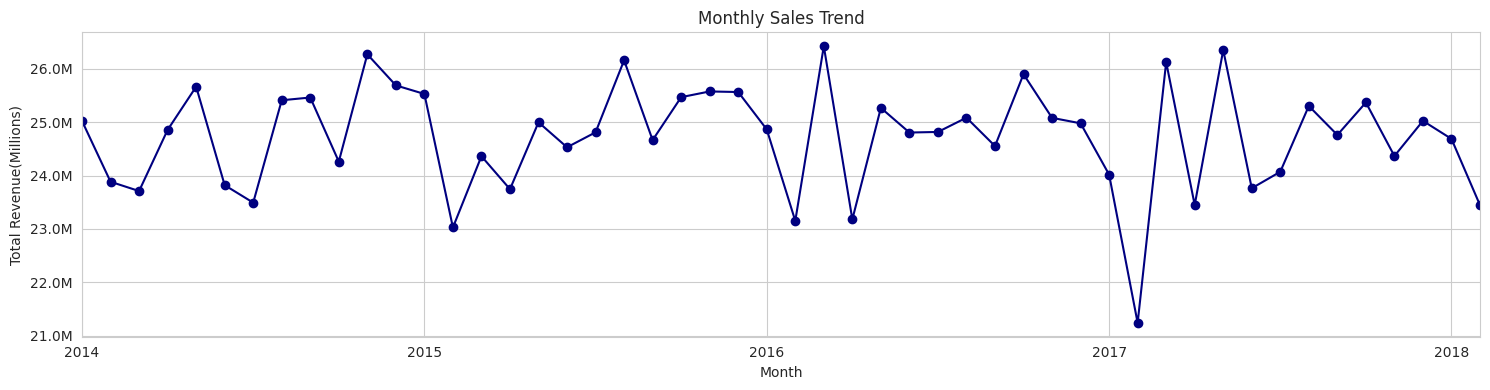

In [ ]:
df['order_month'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('order_month')['revenue'].sum()

plt.figure(figsize =(15,4))

monthly_sales.plot(marker = 'o',color = 'navy')

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue(Millions)')

plt.tight_layout()
plt.show()

 **INSIGHTS ---**

Monthly sales show a stable performance between ~24M-26M with no strong seasonal pattern. While short-term flluctuations and occasional spikes are present, they are irregular. A notable anomaly appears in early 2017 with a sharp dip, suggesting a possible one-time disruption rather than a recurring trend.


🔹 **2. Monthly Sales Trend (Excluding 2018)**

Goal: Highlight overall seasonality patterns by aggregating sales across all years for each calendar month

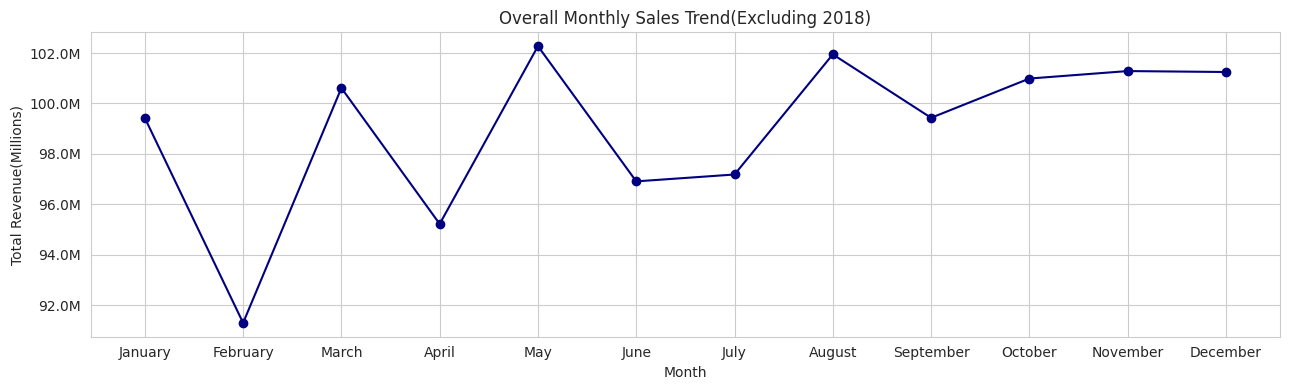

In [ ]:
df_ = df[df['order_date'].dt.year != 2018]

monthly_sales = (df_
.groupby(['order_month_num','order_month_name'])['revenue']
.sum()
.sort_index()
)

from matplotlib.ticker import FuncFormatter

plt.figure(figsize = (13,4))
plt.plot(monthly_sales.index.get_level_values(1),
monthly_sales.values,
marker = 'o',
color = 'navy'
)
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Overall Monthly Sales Trend(Excluding 2018)")
plt.xlabel('Month')
plt.ylabel('Total Revenue(Millions)')

plt.tight_layout()
plt.show()

**INSIGHTS ---**

Sales show seasonal variation, starting strong in January, dipping in February, and peaking in May and August. Performance remains stable and high from August to December, indicating consistent year-end demand.

🔹 **3. Top 10 Products by Revenue (in Millions)**

Goal : Indentify the highest - grossing products to focus marketing and inventory effort

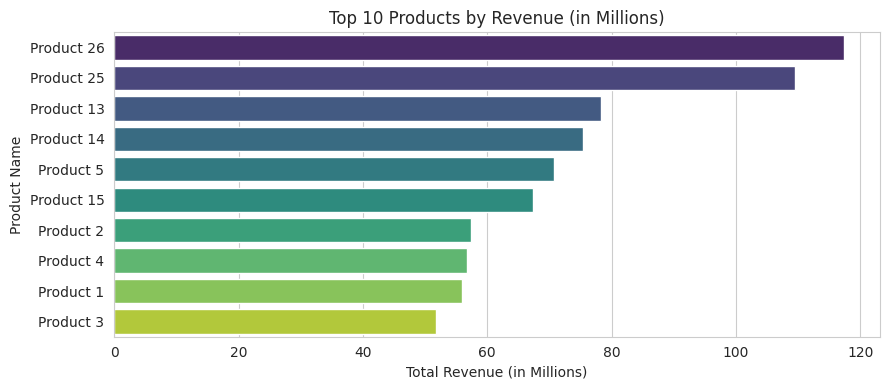

In [ ]:
top_prod = df.groupby('product_name')['revenue'].sum() /1_000_000

top_prod = top_prod.nlargest(10)

plt.figure(figsize =(9,4))

sns.barplot( x=top_prod.values,
            y = top_prod.index,
            palette='viridis')

plt.title('Top 10 Products by Revenue (in Millions)')
plt.xlabel('Total Revenue (in Millions)')
plt.ylabel('Product Name')

plt.tight_layout()

plt.show()

**INSIGHTS ---**

Products 26 and 25 generate highest revenue, with a clear drop in sales for the remaining products.

The lower-performing products have similar revenue levels, showing limited growth. This suggests an opportunity to improve mid and low performing products to increase overall sales.

🔹**4. Top 10 Products by Avg Profit Margin**

Goal: Compare average profitability across products to identify high - margin **items**

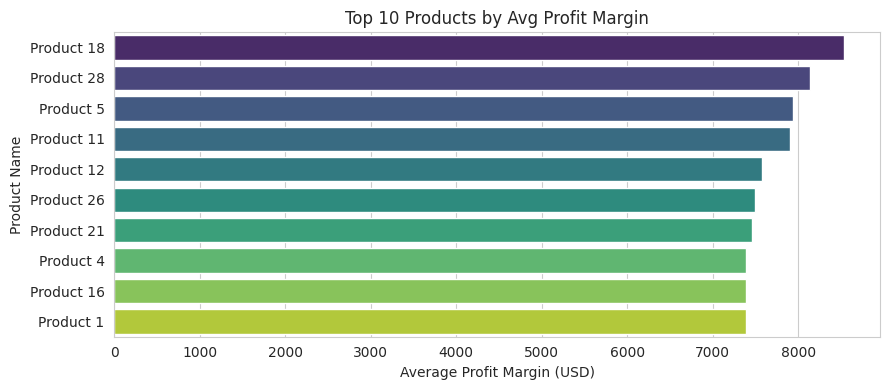

In [ ]:
top_margin = (df.groupby('product_name')['profit'].mean()
.sort_values(ascending = False)
.head(10))

plt.figure(figsize=(9,4))

sns.barplot(x = top_margin.values,
            y = top_margin.index,
            palette = 'viridis')

plt.title('Top 10 Products by Avg Profit Margin')
plt.xlabel('Average Profit Margin (USD)')
plt.ylabel('Product Name')

plt.tight_layout()
plt.show()

**INSIGHTS ---**

Products 18 and 28 have the highest average profit margins, while most other products fall within a similar mid-range.

This shows that only a few products are significantly more profitable. Applying strategies from top-performing products could help improve overall profitability.

🔹 **5. Sales by Channel (Pie Chart)**

Goal: Show distribution of total sales across channels to identify dominant sales routes

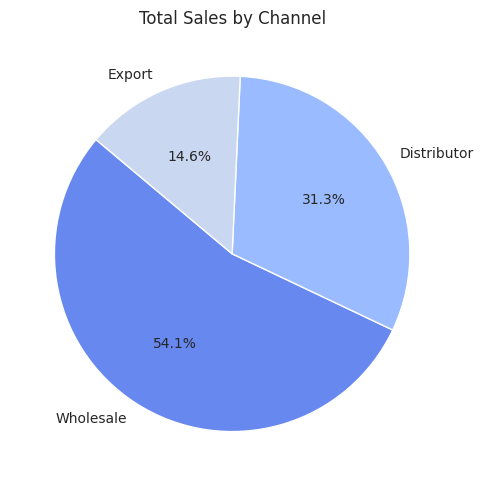

In [ ]:
chan_sales = df.groupby('channel')['revenue'].sum().sort_values(ascending = False)

plt.figure(figsize =(5,5))

plt.pie(chan_sales.values,
         labels=chan_sales.index,
         autopct = '%1.1f%%',
         startangle = 140,
         colors = sns.color_palette('coolwarm'))

plt.title('Total Sales by Channel')

plt.tight_layout()
plt.show()

**INSIGHTS ---**

Wholesale contributes the majority of sales, followed by Distributor,  while Export accounts for a smaller share.

This shows a strong reliance on bulk domestic channels.

 Expanding export operations could help diversify revenue and reduce dependency on a single channel.

🔹**6. Average Order Value(AOV) Distribution**

Goal: Understand distribution of order  values to identify typical spending levels and outliers

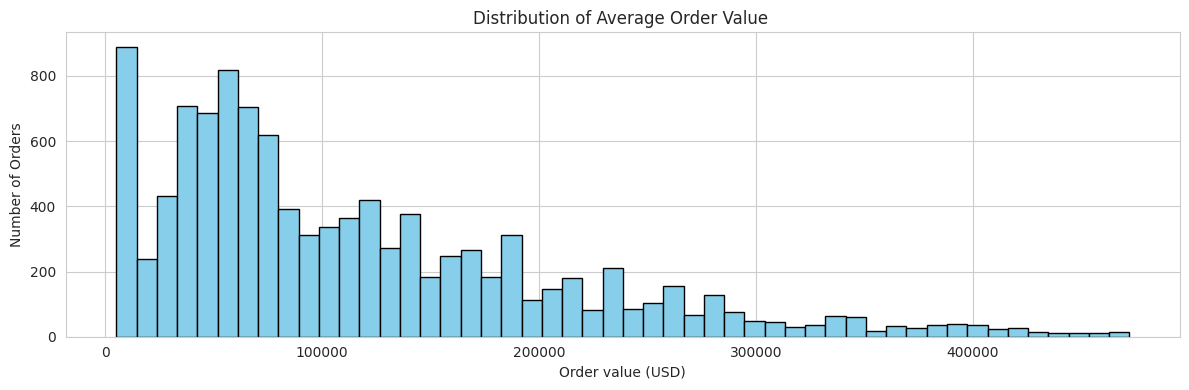

In [ ]:
aov = df.groupby('order_number')['revenue'].sum()

plt.figure(figsize=(12,4))

plt.hist(aov,
         bins = 50,
         color = 'skyblue',
         edgecolor = 'black')

plt.title('Distribution of Average Order Value ')
plt.xlabel('Order value (USD)')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

**INSIGHTS ---**

The order value distribution is right-skewed, with most orders concentrated in the lower range.

 A small number of high-value orders exist, but they represent only a minor share of total transactions.


🔹 **7. Profit Margin% Vs Unit Price**

Goal: Examine relationship between unit price and profit margin percentage across orders

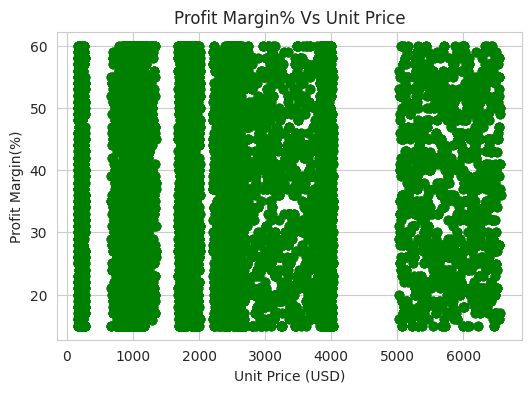

In [ ]:
df['profit_margin_pct'] =(df['profit']/df['revenue'])*100

plt.figure(figsize=(6,4))

plt.scatter(
    df['unit_price'],
    df['profit_margin_pct'],
    alpha = 0.6,
    color = 'green'
)

plt.title('Profit Margin% Vs Unit Price')
plt.xlabel('Unit Price (USD)')
plt.ylabel('Profit Margin(%)')

plt.tight_layout
plt.show()

**INSIGHTS ---**

Profit margins vary across all price levels, with no clear relationship between unit price and margin. Most products follow similar margin ranges, indicating consistent pricing strategies. A few low-margin cases may highlight areas for improvement.


🔹 **8. Unit Price Distribution per Product**

  Goal: Compare pricing variablity across different products to identify price consistency and outliers

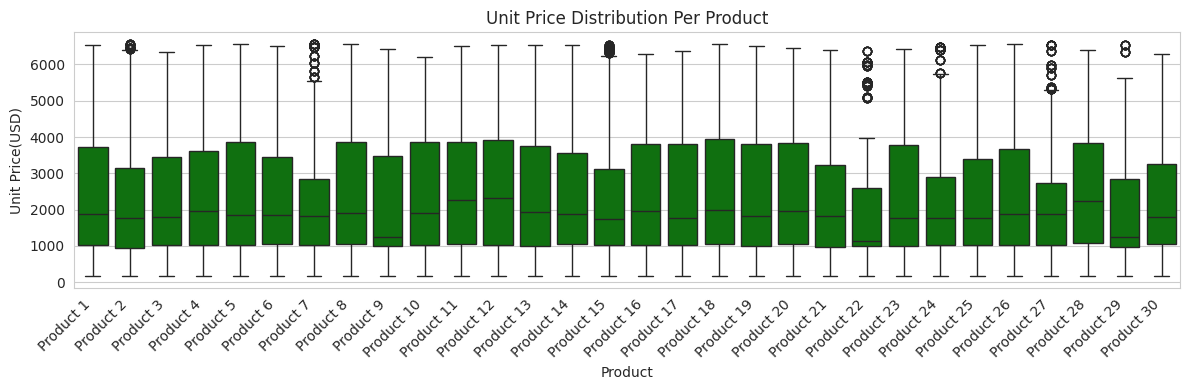

In [ ]:
plt.figure(figsize=(12,4))

sns.boxplot(data = df,x='product_name',y='unit_price',color='g')

plt.title('Unit Price Distribution Per Product')
plt.xlabel('Product')
plt.ylabel('Unit Price(USD)')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**INSIGHTS---**

Most products show a consistent price range, with a few extreme high and low values observed.

These outliers may influence overall pricing analysis and should be reviewed to ensure accurate insights.

🔹 **9. Total Sales  by US Region**

Goal: Compare total sales across U.S. regions to identify top-performing markets and areas for targeted growth.

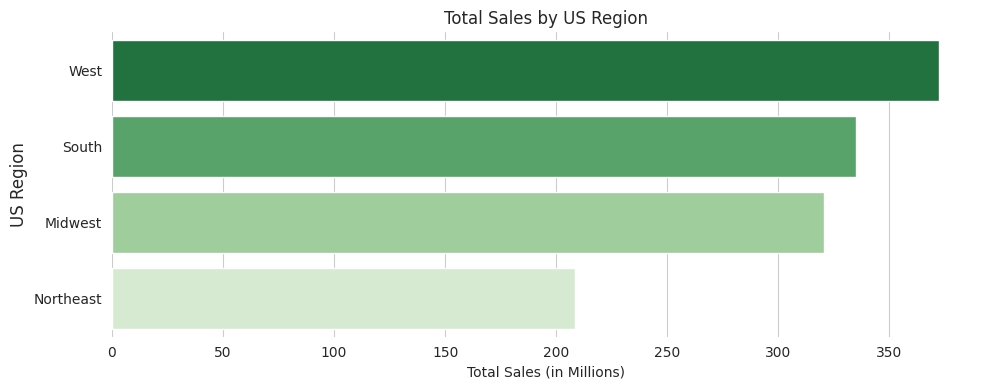

In [ ]:
region_sales = (df.groupby('us_region')['revenue'].sum()
.sort_values(ascending = False)/1e6
)

plt.figure(figsize=(10,4))
sns.barplot(x=region_sales.values,
            y=region_sales.index,
            palette='Greens_r')

plt.title('Total Sales by US Region')
plt.xlabel('Total Sales (in Millions)')
plt.ylabel('US Region' ,fontsize = 12)
plt.xticks(rotation=0)
sns.despine(left=True,bottom = True)

plt.tight_layout()
plt.show()


**INSIGHTS---**

The West region leads in total sales, followed by the South and Midwest, which also show strong performance. The Northeast contributes the least, indicating an opportunity for growth.

Focusing on improving performance in the Northeast while maintaining strength in leading regions could enhance overall results.

🔹**10. Total Sales  by State(Choropleth Map)**

Goal:Visualize geographic distribution of sales to identify high and low performing states and incover regional gaps

In [ ]:
import plotly.express as px

# Aggregate revenue by state(in millions)

state_sales = (df.groupby('state')['revenue'].sum().reset_index())

state_sales['revenue_m'] = state_sales['revenue']/1e6

fig = px.choropleth(
    state_sales,
    locations = 'state',
    locationmode = 'USA-states',
    color = 'revenue_m',
    scope ='usa',
    labels={'revenue_m':'Total Sales (M USD)'},
    color_continuous_scale = 'Blues',
    hover_data ={'revenue_m':':.2f'}
)

fig.update_layout(
    title_text='Total Sales by State',
    margin=dict(l=0, r=0, t=40, b=0),
    coloraxis_colorbar=dict(
        title='Sales (M USD)',
        ticksuffix='M'))

fig.show()

**INSIGHTS---**

Sales are concentrated in a few leading states, with California at the top.

Mid-tier states perform consitently but lag behind,while several states contribute less.

This highlights uneven regional performance and growth opportunities.

Focusing on strengthening top-performing states while improving performance in lower-contributing regions can help drive overall growth.

🔹 **11. Top 10 States by Revenue and Order Count**

Goal: Identify highest revenue-generating states and compare their order volumes

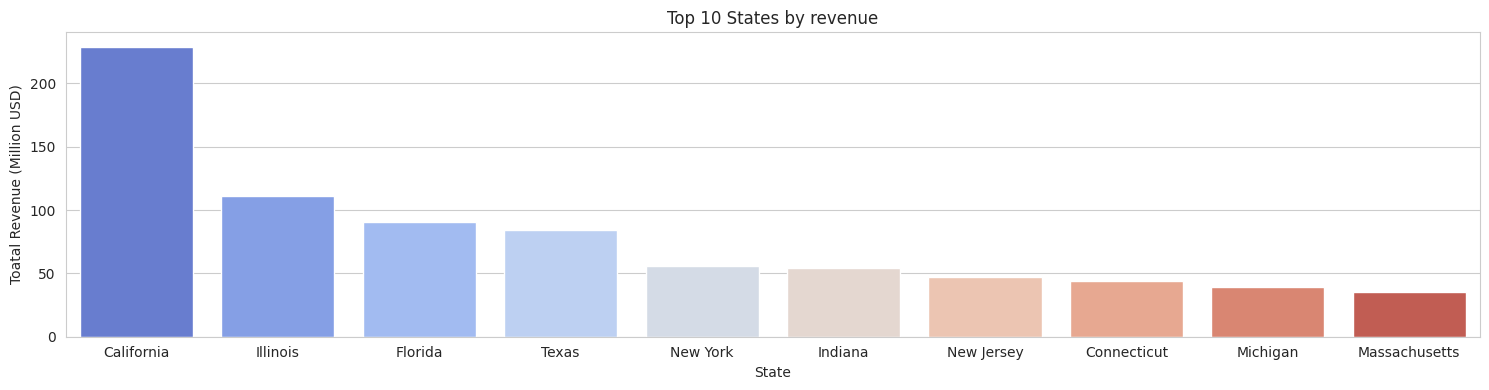

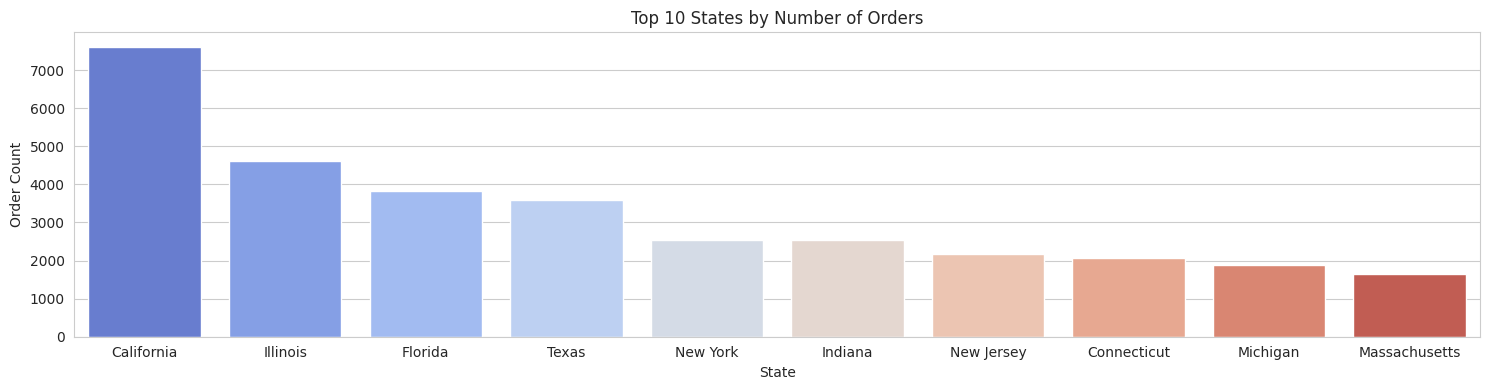

In [ ]:
# Average total_revenue and unique order count per state

state_rev = (df.groupby('state_name').agg(
    revenue =('revenue','sum'),
    orders=('order_number','nunique'))
.sort_values('revenue',ascending=False).head(10))
state_rev

# Plot1: Total 10 States by revenue
plt.figure(figsize=(15,4))
sns.barplot(
    x=state_rev.index,
    y=state_rev['revenue']/1e6,
    palette='coolwarm'
)

plt.title('Top 10 States by revenue')
plt.xlabel('State')
plt.ylabel('Toatal Revenue (Million USD)')

plt.tight_layout()
plt.show()

# Plot 2: Total 10 States by orders

plt.figure(figsize=(15,4))
sns.barplot(
    x=state_rev.index,
    y=state_rev['orders'],
    palette = 'coolwarm'
)

plt.title('Top 10 States by Number of Orders')
plt.xlabel('State')
plt.ylabel('Order Count')

plt.tight_layout()
plt.show()



**INSIGHTS---**

California leads in both revenue and number of orders, clearly outperforming other states. Illinois and Florida also show strong performace, while the remaining states contribute gradually lower revenue and order volumes.

The similar pattern across both chart suggest that higher sales are driven by higher order volumes, highlighting key regions that significantly impact overall performace.

🔹 **12. Average Profit Margin by Channel**

Goal: Compare average profit margins across sales channels to identify the most
and least profitable routes



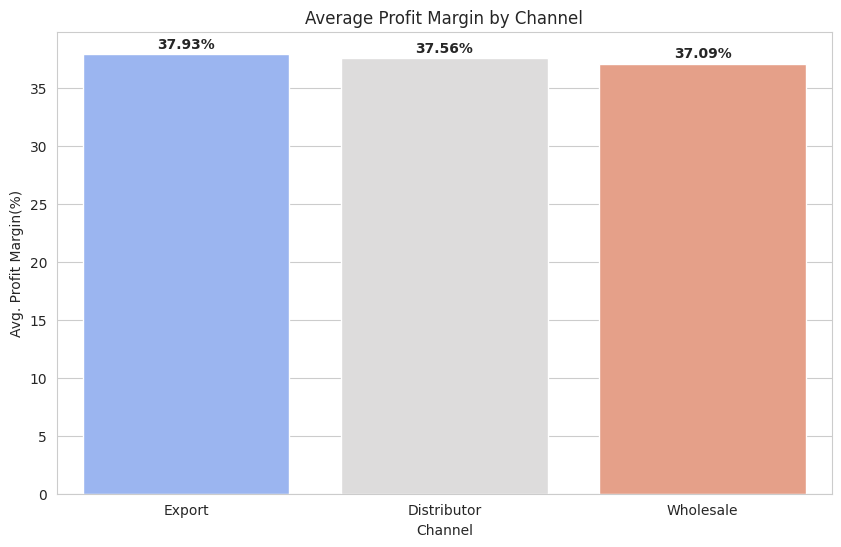

In [ ]:
# Compute average profit margin percentage for each channel

channel_margin = (df.groupby('channel')['profit_margin_pct'].mean()
.sort_values(ascending=False))

plt.figure(figsize=(10,6))

ax = sns.barplot(x=channel_margin.index,
                 y=channel_margin.values,
                 palette = 'coolwarm')

plt.title('Average Profit Margin by Channel')
plt.xlabel('Channel')
plt.ylabel('Avg. Profit Margin(%)')

for i, v in enumerate(channel_margin.values):
  ax.text(i,
          v + 0.5,
          f"{v:.2f}%",
          ha = 'center',
          fontweight = 'bold')
  plt.tight_layout
plt.show()

**INSIGHTS---**

Profit margins are similar across all channels, with Export slightly leading, followed closely by Distributor and Wholesale.

The minimal variation indicates consistent profitability across channels, suggesting that no single channel significantly outperforms other in terms of margin.

🔹 **13. Top and Bottom 10 Customers by Revenue**

Goal: Identify your highest- and lowest-revenue customers to tailor engagement strategies

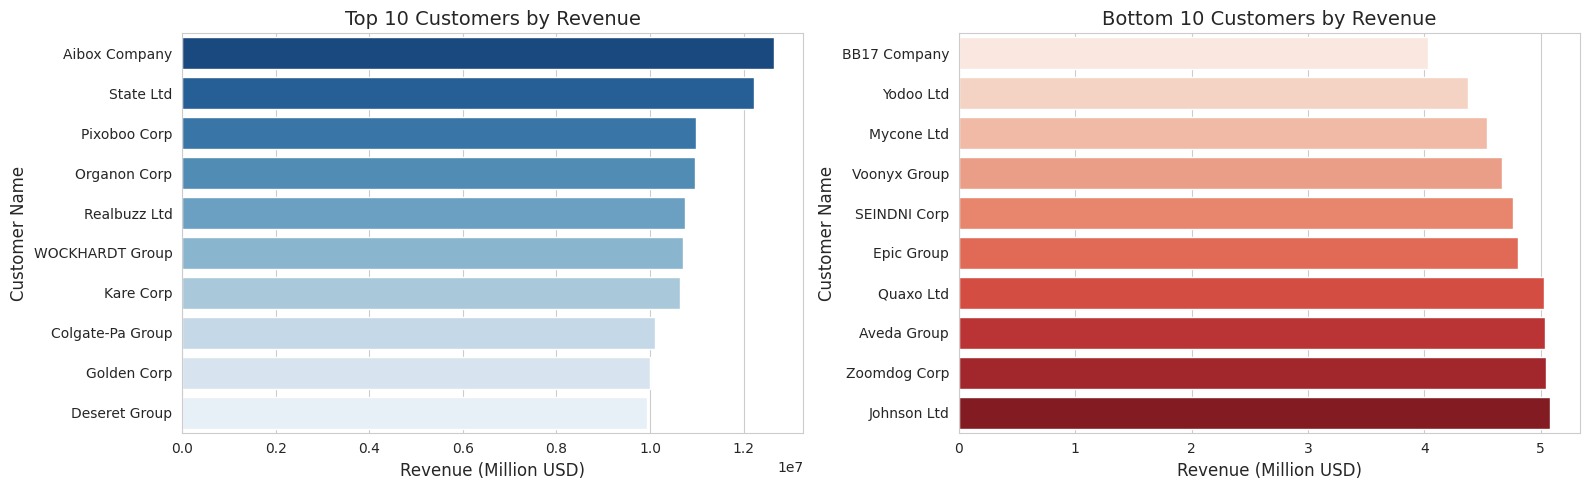

In [ ]:
top_rev = (df.groupby('customer_name')['revenue']
           .sum()
           .sort_values(ascending = False)
           .head(10))

bottom_rev = (df.groupby('customer_name')['revenue']
           .sum()
           .sort_values(ascending = True)
           .head(10))

fig, axes = plt.subplots(1,2,figsize=(16,5))

# Plot1

sns.barplot(x = top_rev.values,y = top_rev.index,palette = 'Blues_r',
            ax=axes[0])

axes[0].set_title('Top 10 Customers by Revenue', fontsize = 14)
axes[0].set_xlabel('Revenue (Million USD)', fontsize = 12)
axes[0].set_ylabel('Customer Name',fontsize=12)

# Plot2
sns.barplot(
    x = bottom_rev.values/1e6,
    y=bottom_rev.index,
    palette = 'Reds',
    ax = axes[1]
)

axes[1].set_title('Bottom 10 Customers by Revenue', fontsize = 14)
axes[1].set_xlabel('Revenue (Million USD)', fontsize = 12)
axes[1].set_ylabel('Customer Name',fontsize=12)

plt.tight_layout()
plt.show()

**INSIGHTS---**

Aibox Company,State Ltd, and Pixobo Corp are the leading revenue contributors.

Customers such as Johnson Ltd and Zoomdog Corp generate comparatively lower revenue

This indicates a concentration of revenue among a few key customers, highlighting the need to retain top clients while improving performace across broader customer base.


🔹**14. Customer Segmentation: Revenue VS. Profit Margin**

Goal: Segment customers by total revenue and average profit margin, highlighting order volume

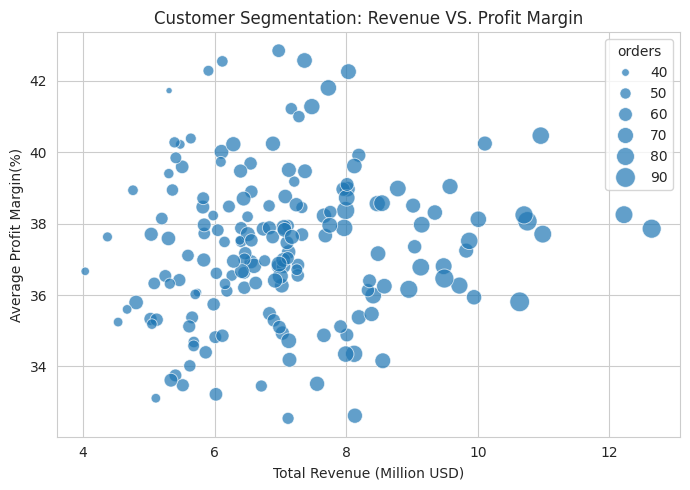

In [ ]:
cust_summary =(df.groupby('customer_name').agg(
    total_revenue =('revenue','sum'),
    total_profit = ('profit','sum'),
    avg_margin = ('profit_margin_pct', 'mean'),
    orders=('order_number','nunique')
))

cust_summary['total_revenue_m'] = cust_summary['total_revenue'] /1e6

plt.figure(figsize=(7,5))

sns.scatterplot(
    data =cust_summary,
    x = 'total_revenue_m',
    y = 'avg_margin',
    size = 'orders',
    sizes = (20,200),
    alpha = 0.7
)

plt.title('Customer Segmentation: Revenue VS. Profit Margin')
plt.xlabel('Total Revenue (Million USD)')
plt.ylabel('Average Profit Margin(%)')

plt.tight_layout()
plt.show()

**INSIGHTS---**

Customers are distributed across a range of revenue and profit margin levels, with most concentrated in the mid-range.

There is no strong relationship between revenue and profit margin, as both high and low revenue customers exhibit similar margin levels.

This suggests that profitability remains relatively consistent across customers,regardless of their revenue contributions



🔹 **15. Correlation Heatmap of Numeric Features**

Goal: Identify relationships among key numeric variables to uncover potential multicollinearity

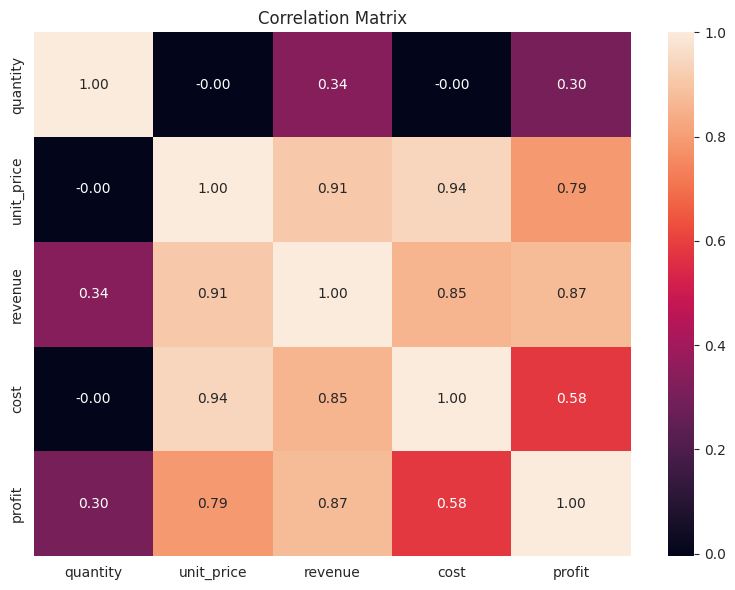

In [ ]:
num_cols = ['quantity','unit_price','revenue','cost','profit']

corr= df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot = True,
            fmt =".2f")
plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

Profit and revenue are strongly correlated, indicating that as sales increase, profit also rises.

Unit price is a key driver, showing strong relationships with revenue,profit, and cost, highlighting the impact of pricing decisons on overall performance.

Cost is closely linked to revenue but has a moderate relationship with profit, suggesting that higher sales also bring higher expenses.

Quantity shows weak relationship with other variables, indicating that volume plays a smaller role compared to pricing.

In [ ]:
# Export Final Dataframe to CSV
df.to_csv('Sales_data(EDA Exported).csv',index = False)

# Key Insights


*  **Monthly Revenue Cycle:**

   Revenue stays stable between
   (23M-26.5M) across 2014-2017, with no consistent seasonal spikes. Sharpest drop (~21.2) occurs in early 2017, indicating a possible one-time disruption.

*   **Channel Mix:**

     Wholesale (54%) dominates, followed by Distributors (31%) and Exports (15%), indicating an opportunity to expand international presence.
    
*    **Top Products (Revenue):**
     
     Product 26 (≈118M) and Product 25 (≈110M) lead significantly, followed by Product 13 (≈78M). Mid-tier products fall in the (≈68–75M) range, while lower-tier products contribute around (≈52–57M).

*   **Profit Margins:**

     Profit margins range broadly from ≈18% to ≈60%, with no strong correlation to unit price. Dense horizontal bands suggest standardized pricing strategies across tiers.

*    **Seasonal Volume:**

     No strong seasonal pattern is observed, although slight fluctuations occur. The early 2017 dip (≈21.2M) may require further investigation.

*   **Regional Performance:**

     California leads with ≈230M revenue and 7,500+ orders, followed by Illinois, Florida, and Texas at ≈85–110M revenue and 3,500–4,500 orders. Other states such as New York and Indiana contribute around ≈54M revenue with 2,000+ orders, indicating uneven regional performance.
     





